# Task 5 · Step 3 — SVAMP transfer and feedback-source synthesis

**Feedback sources.** RLVR uses the exact final-answer checker, $r_{\text{RLVR}}(x,y)=\mathbb{1}[\text{verifier}(y)=\text{gold}(x)]$, where the verifier extracts the **last** `#### <number>` field (numbers elsewhere are ignored). RLAIF uses a direct group reward from the fixed pairwise judge: for the $K$ responses to one prompt, $r_{\text{RLAIF}}(y_k)=\frac{\text{wins}(y_k)+0.5\,\text{ties}(y_k)}{K-1}$. The judge (`Qwen2.5-3B-Instruct`, 4-bit, greedy, 4 new tokens) receives the rubric, the problem and two candidates in a deterministic hash-based A/B orientation and must answer A, B or TIE; the released parser keeps the first of A/B/TIE it finds (no match → TIE).

**Policies.** SFT = base `Qwen2.5-1.5B-Instruct`; RLVR and RLAIF = the supplied frozen adapters (same base, same GSM8K prompt indices, group optimiser, group size, completion cap and approximately matched token budget). All policies answer with greedy decoding, cap 512 tokens, using the exact course prompts.

**AI pairwise win rate.** win = 1, tie = 0.5, loss = 0, averaged over the fixed set; explicit ties and ambiguous judge outputs are reported separately.

**Transfer set.** The fixed 100-example SVAMP challenge subset (`data/math_transfer_eval.jsonl`, first 100 in official order), evaluated without retraining with the same verifier and judge protocol.

**Research question (RQ4).** Which behaviours transfer to the out-of-domain set, and what evidence supports or weakens the claim that either feedback source promotes more general reasoning behaviour?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task5_feedback.evaluate_math --config configs/feedback.yaml --dataset transfer')
    run('python -m task5_feedback.compare_feedback --config configs/feedback.yaml')
    run('python -m task5_feedback.judge_ambiguity --config configs/feedback.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. SVAMP results and drop from GSM8K

In [3]:
POL = ["sft", "rlvr", "rlaif"]
T = load("task5_feedback/math_eval_transfer.json"); Gk = load("task5_feedback/math_eval_gsm.json"); F = load("task5_feedback/feedback_synthesis.json")
pd.DataFrame({p.upper(): {"GSM8K accuracy": Gk["per_policy"][p]["exact_accuracy"], "SVAMP accuracy": ci_text(T["per_policy"][p]["exact_accuracy"], T["per_policy"][p]["exact_accuracy_ci95"]),
                          "drop (GSM − SVAMP)": F["drops"][p]["accuracy_drop"], "GSM format": F["drops"][p]["gsm_format"], "SVAMP format": F["drops"][p]["transfer_format"],
                          "GSM length": F["drops"][p]["gsm_len"], "SVAMP length": F["drops"][p]["transfer_len"],
                          **{f"SVAMP {k}": v for k, v in T["per_policy"][p]["failure_types"].items()}} for p in POL}).T

,GSM8K accuracy,SVAMP accuracy,drop (GSM − SVAMP),GSM format,SVAMP format,GSM length,SVAMP length,SVAMP correct,SVAMP wrong_final_answer,SVAMP no_final_format,SVAMP no_final_format_hit_cap
SFT,0.2833,"44.0% [35, 54]",-0.1567,0.35,0.57,274.33,163.96,0.44,0.13,0.43,0.0
RLVR,0.2867,"46.0% [37, 56]",-0.1733,0.36,0.59,275.8767,164.07,0.46,0.13,0.41,0.0
RLAIF,0.2867,"44.0% [35, 54]",-0.1533,0.36,0.57,275.45,162.98,0.44,0.13,0.43,0.0


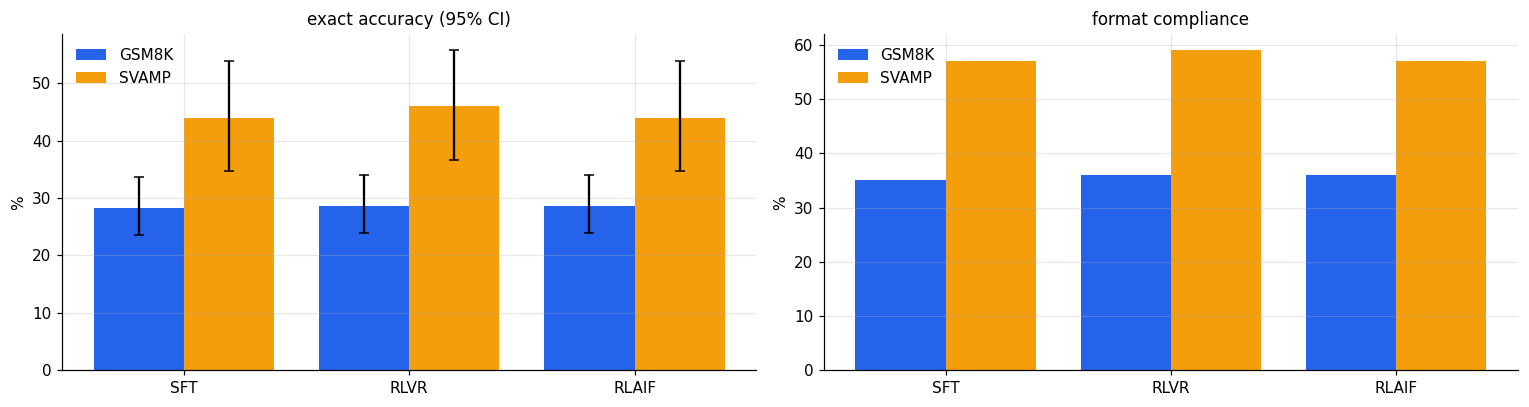

,SFT,RLVR,RLAIF,n
Addition,0.250,0.250,0.250,20
Common-Division,0.429,0.429,0.429,14
Multiplication,0.111,0.111,0.111,9
Subtraction,0.561,0.596,0.561,57


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8)); x = np.arange(3)
for off, src, lab, c in [(-0.2, Gk, "GSM8K", "#2563EB"), (0.2, T, "SVAMP", "#F59E0B")]:
    acc = np.array([src["per_policy"][p]["exact_accuracy"] for p in POL]) * 100; ci = np.array([src["per_policy"][p]["exact_accuracy_ci95"] for p in POL]) * 100
    ax[0].bar(x + off, acc, 0.4, yerr=[np.clip(acc - ci[:, 0], 0, None), np.clip(ci[:, 1] - acc, 0, None)], capsize=3, color=c, label=lab)
    ax[1].bar(x + off, [src["per_policy"][p]["format_compliance_rate"] * 100 for p in POL], 0.4, color=c, label=lab)
for a, t in zip(ax, ["exact accuracy (95% CI)", "format compliance"]):
    a.set_xticks(x); a.set_xticklabels([p.upper() for p in POL]); a.set_ylabel("%"); a.set_title(t); a.legend()
fig.tight_layout(); plt.show()
Tq = pd.DataFrame([json.loads(l) for l in open("data/math_transfer_eval.jsonl", encoding="utf-8")])
Gt = {p: pd.DataFrame(jl(f"task5_feedback/generations_transfer_{p}.jsonl")) for p in POL}
by = pd.DataFrame({p.upper(): pd.Series(Gt[p].exact_correct.values, index=Tq.svamp_type.values).groupby(level=0).mean() for p in POL})
by["n"] = Tq.svamp_type.value_counts(); by.round(3)

## 2. Pairwise judge on SVAMP

In [5]:
AMB = load("task5_feedback/judge_ambiguity.json") if exists("task5_feedback/judge_ambiguity.json") else {}
pd.DataFrame({k.replace("_vs_", " vs ").upper(): {"SVAMP win rate (tie = 0.5)": v["win_rate_a_ties_half"], "GSM8K win rate": Gk["pairwise_comparisons"][k]["win_rate_a_ties_half"],
              "decisive A/B outputs": AMB.get("transfer", {}).get(k, {}).get("decisive"), "explicit TIE": AMB.get("transfer", {}).get(k, {}).get("explicit_tie"),
              "ambiguous (option echo)": AMB.get("transfer", {}).get(k, {}).get("ambiguous")} for k, v in T["pairwise_comparisons"].items()}).T

,SVAMP win rate (tie = 0.5),GSM8K win rate,decisive A/B outputs,explicit TIE,ambiguous (option echo)
RLAIF VS SFT,0.525,0.4950,0.0,79.0,21.0
RLVR VS SFT,0.515,0.5033,0.0,79.0,21.0
RLVR VS RLAIF,0.530,0.5067,0.0,80.0,20.0


## 3. Feedback-source comparison (all measured)

In [6]:
pd.DataFrame(F["feedback_source_table"]).T.rename(columns={"verifier": "exact verifier", "ai_judge": "AI judge"})

,exact verifier,AI judge
coverage: decisive on RLAIF-vs-SFT pairs,0.02,0.04
coverage: S_reason (reasoning-only change),0.00,0.00
coverage: S_outcome (final-answer change),1.00,0.00
noise: A/B order-consistent decisions,1.00 (deterministic),0.89
noise: agrees w/ verifier when verifier decides,—,0.00
exploit: prefers persuasive filler,0.00,0.25
exploit: prefers gold-distractor (wrong final),0.00,0.05
cost: seconds per reward call,1.1e-06,0.50
cost: calls per K=4 group,4,6 (all pairs)


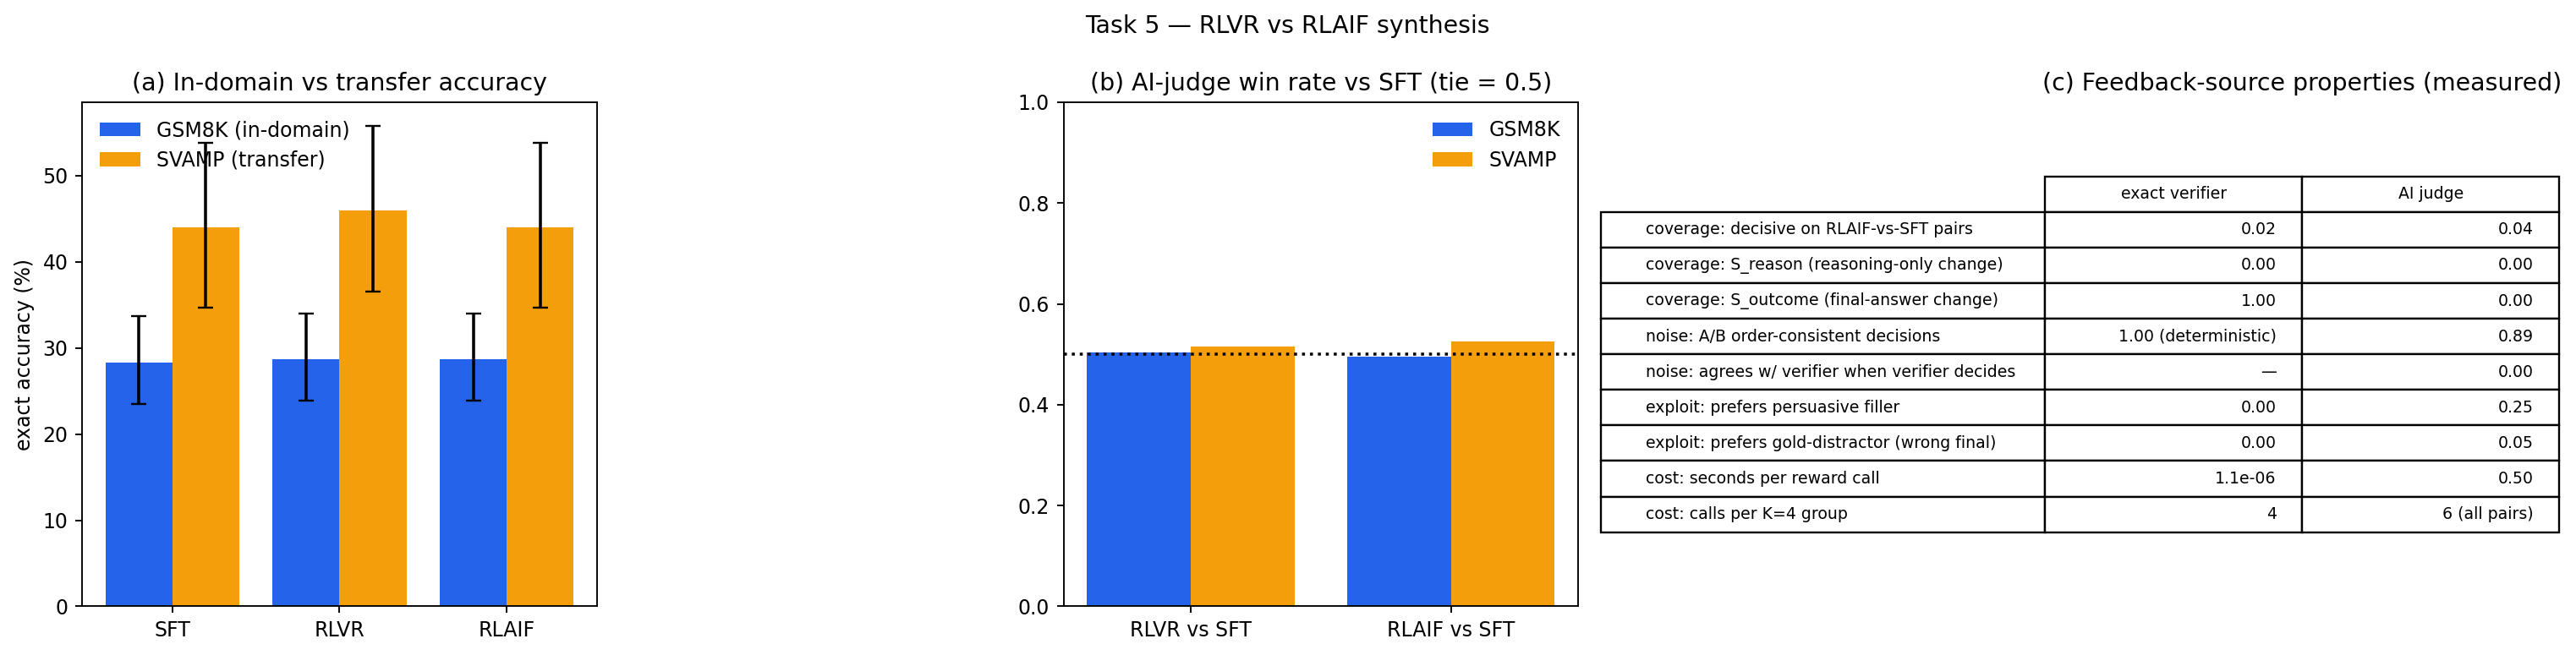

In [7]:
display(Image(filename=str(FIG / "task5_feedback_synthesis_dashboard.png"), width=1100))

## 4. SVAMP examples

In [8]:
for p in ["rlvr", "rlaif"]:
    g = Gt[p]; w = g[~g.exact_correct].iloc[0]
    side_by_side(f"{p.upper()} — incorrect on SVAMP (gold {w.gold}, failure: {w.failure_type})", w.problem, {"response": w.response},
                 meta={"response": f"pred {w.pred_final} · {w.response_tokens} tok"}, limit=600)

"responsepred nan · 85 tokTo calculate the final price after applying the discount, we need to subtract the discount from the original price.Original price per pack: $76Discount per pack: $25Final price = Original price - DiscountFinal price = $76 - $25Final price = $51Therefore, you would have to pay **$51** to buy each pack after the discount."


"responsepred nan · 85 tokTo calculate the final price after applying the discount, we need to subtract the discount from the original price.Original price per pack: $76Discount per pack: $25Final price = Original price - DiscountFinal price = $76 - $25Final price = $51Therefore, you would have to pay **$51** to buy each pack after the discount."


## 5. Facts for RQ4

In [9]:
for p in POL:
    d = F["drops"][p]
    print(f"{p.upper():5s} GSM {d['gsm_accuracy']:.3f} → SVAMP {d['transfer_accuracy']:.3f} (drop {d['accuracy_drop']:+.3f}); format {d['gsm_format']:.2f} → {d['transfer_format']:.2f}; length {d['gsm_len']:.0f} → {d['transfer_len']:.0f}")
for k in ["rlvr_vs_sft", "rlaif_vs_sft"]:
    print(f"{k}: win rate GSM {F['drops'][k]['gsm_win_rate']:.3f} → SVAMP {F['drops'][k]['transfer_win_rate']:.3f}; SVAMP decisive judge outputs {AMB.get('transfer', {}).get(k, {}).get('decisive')}")

SFT   GSM 0.283 → SVAMP 0.440 (drop -0.157); format 0.35 → 0.57; length 274 → 164
RLVR  GSM 0.287 → SVAMP 0.460 (drop -0.173); format 0.36 → 0.59; length 276 → 164
RLAIF GSM 0.287 → SVAMP 0.440 (drop -0.153); format 0.36 → 0.57; length 275 → 163
rlvr_vs_sft: win rate GSM 0.503 → SVAMP 0.515; SVAMP decisive judge outputs 0
rlaif_vs_sft: win rate GSM 0.495 → SVAMP 0.525; SVAMP decisive judge outputs 0
